In [1]:
import pandas as pd
import json
import re
import time
import random
import os
from datetime import datetime
from together import Together

# Define the Together API key - replace with your actual key
TOGETHER_API_KEY = "tgp_v1_TVGh1rZPV7mbG2OViwgu9UOzKznqo1q-Z_9SgBBD_fc"
client = Together(api_key=TOGETHER_API_KEY)

def query_together(prompt, max_retries=5):
    for attempt in range(max_retries):
        try:
            if attempt > 0:
                base_delay = min(30, 2 ** attempt)
                jitter = random.uniform(0, 0.5 * base_delay)
                wait_time = base_delay + jitter
                print(f"Attempt {attempt+1}/{max_retries} - Waiting {wait_time:.2f} seconds before retry...")
                time.sleep(wait_time)

            print(f"Sending request (attempt {attempt+1}/{max_retries})...")
            response = client.chat.completions.create(
                model="meta-llama/Llama-3.3-70B-Instruct-Turbo-Free",
                messages=[
                    {"role": "system", "content": "You are a biomedical expert specializing in Gene Ontology (GO). Always respond in valid JSON format."},
                    {"role": "user", "content": prompt}
                ],
                temperature=0.1,
                response_format={"type": "json_object"}
            )

            content = response.choices[0].message.content
            return content

        except Exception as e:
            print(f"Request error: {str(e)}")

    return json.dumps({"GO_TERM": "Error"})

def extract_go_data(response_text):
    try:
        try:
            json_obj = json.loads(response_text.strip())
            if 'GO_TERM' in json_obj:
                return json_obj
        except json.JSONDecodeError:
            pass

        json_match = re.search(r'```(?:json)?\s*(\{.*?\})\s*```', response_text, re.DOTALL)
        if json_match:
            try:
                json_obj = json.loads(json_match.group(1))
                if 'GO_TERM' in json_obj:
                    return json_obj
            except json.JSONDecodeError:
                pass

        json_pattern = re.compile(r'(\{[^{]*?"GO_TERM"[^}]*?\})', re.DOTALL)
        json_match = json_pattern.search(response_text)
        if json_match:
            try:
                json_obj = json.loads(json_match.group(1))
                if 'GO_TERM' in json_obj:
                    return json_obj
            except json.JSONDecodeError:
                pass

        go_term_match = re.search(r'GO_TERM["\':\s]+([^"\'}\s,]+)', response_text)
        if go_term_match:
            return {"GO_TERM": go_term_match.group(1).strip()}

        if re.search(r'[Nn]o(ne| relevant| matching)', response_text) or "not found" in response_text.lower():
            return {"GO_TERM": "None"}

        return {"GO_TERM": "Parse_Error"}

    except Exception as e:
        print(f"JSON parsing error: {e}")
        print(f"Response text: {response_text[:200]}...")
        return {"GO_TERM": "Parse_Error"}

def get_go_term_from_id(go_id):
    prompt = f"""
You are a biomedical expert. Your task is to identify the most general, accurate Gene Ontology (GO) term for the given GO ID. Avoid choosing overly specific subcomponents (e.g., "vesicle lumen") if the broader term (e.g., "vesicle") is more appropriate.

GO ID: "{go_id}"

IMPORTANT: Respond using this exact JSON format:
{{
  "GO_TERM": "<best matching GO term>"
}}

If no valid GO term exists, return:
{{
  "GO_TERM": "None"
}}

Only use valid, officially defined GO terms. Do not guess or invent.
"""

    response_text = query_together(prompt)
    result = extract_go_data(response_text)

    log_entry = {
        "go_id": go_id,
        "raw_response": response_text,
        "extracted_result": result
    }

    with open("go_api_responses.jsonl", "a") as f:
        f.write(json.dumps(log_entry) + "\n")

    return result.get("GO_TERM", "Error")

def calculate_match(original_go_term, new_go_term):
    if pd.isna(original_go_term) or pd.isna(new_go_term):
        return 0
    return int(str(original_go_term).strip() == str(new_go_term).strip())

def main():
    print("Starting GO ID to term mapping process...")

    if not os.path.exists("go_api_responses.jsonl"):
        open("go_api_responses.jsonl", "w").close()

    print("Testing API connection...")
    test_result = get_go_term_from_id("GO:0006915")
    print(f"Test result: {test_result}")

    if test_result in ["Error", "API_Error"]:
        print("API test failed. Please check your API key and connection.")
        return

    print("API test successful, proceeding with batch processing...")

    input_file = "Datasets/go_terms.csv"
    if not os.path.exists(input_file):
        print(f"Error: Input file '{input_file}' not found.")
        return

    df = pd.read_csv(input_file)
    print(f"Loaded {len(df)} rows from {input_file}")
    print(f"Columns in the dataset: {list(df.columns)}")

    df["newgoterm"] = None
    df["match_result"] = None

    total_rows = len(df)
    for idx, (index, row) in enumerate(df.iterrows()):
        try:
            go_id = row["go_id"]
            original_go_term = row["go_term"]

            print(f"Processing {idx+1}/{total_rows}: {go_id}")
            new_go_term = get_go_term_from_id(go_id)

            df.at[index, "newgoterm"] = new_go_term
            df.at[index, "match_result"] = calculate_match(original_go_term, new_go_term)

            print(f"  Original: {original_go_term}, New: {new_go_term}, Match: {df.at[index, 'match_result']}")

            if idx % 10 == 0 or idx == total_rows - 1:
                excluded_columns = ['normalized_term', 'normalized_id', 'go_match', 'processing_time']
                progress_columns = [col for col in df.columns if col not in excluded_columns]
                progress_df = df[progress_columns].copy()
                progress_df.to_csv("ZS_go_llama_results_progress.csv", index=False)
                print(f"Progress saved. Processed {idx+1}/{total_rows} terms.")

            if idx < total_rows - 1:
                delay = random.uniform(1, 3)
                print(f"Waiting {delay:.2f} seconds before next request...")
                time.sleep(delay)

        except Exception as e:
            print(f"Error processing row {idx}: {e}")
            df.at[index, "newgoterm"] = "Error"
            df.at[index, "match_result"] = 0

    excluded_columns = ['normalized_term', 'normalized_id', 'go_match', 'processing_time']
    final_columns = [col for col in df.columns if col not in excluded_columns]
    final_df = df[final_columns].copy()
    final_df.to_csv("ZS_go_llama_results_final.csv", index=False)

    print(f"\n=== FINAL RESULTS ===")
    if "match_result" in df.columns:
        total_matches = df["match_result"].sum()
        total_processed = len(df)

        none_results = (df["newgoterm"] == "None").sum()
        error_results = (df["newgoterm"] == "Error").sum()
        parse_error_results = (df["newgoterm"] == "Parse_Error").sum()
        valid_results = total_processed - none_results - error_results - parse_error_results

        print(f"Total terms processed: {total_processed}")
        print(f"Correct matches: {total_matches}")
        print(f"Match rate: {(total_matches / total_processed) * 100:.2f}%")
        print(f"\nResults breakdown:")
        print(f"  - Valid GO terms returned: {valid_results}")
        print(f"  - No match found (None): {none_results}")
        print(f"  - API errors: {error_results}")
        print(f"  - Parse errors: {parse_error_results}")

        valid_matches = df[~df["newgoterm"].isin(["None", "Error", "Parse_Error"])]["match_result"].sum()
        valid_accuracy = (valid_matches / valid_results) * 100 if valid_results > 0 else 0.0
        print(f"  - Accuracy among valid results: {valid_accuracy:.2f}%")
        print(f"\nACCURACY (valid results only): {valid_accuracy:.2f}%")

        if 'Aspect' in df.columns:
            print(f"\nBreakdown by GO Aspect:")
            aspect_stats = df.groupby('Aspect').agg({
                'match_result': ['count', 'sum', 'mean']
            }).round(3)
            print(aspect_stats)

    print(f"\nProcessing completed!")
    print(f"Final results saved to: ZS_go_llama_results_final.csv")
    print(f"Progress file: ZS_go_llama_results_progress.csv")
    print(f"Log file: go_api_responses.jsonl")
    print(f"Columns excluded from output: normalized_term, normalized_id, go_match, processing_time")

if __name__ == "__main__":
    main()


Starting GO ID to term mapping process...
Testing API connection...
Sending request (attempt 1/5)...
Test result: apoptotic process
API test successful, proceeding with batch processing...
Loaded 1839 rows from Datasets/go_terms.csv
Columns in the dataset: ['go_id', 'go_annotations', 'go_term', 'Definitions', 'Parents', 'Aspect', 'go_id_pmc', 'go_term_pmc', 'normalized_term', 'normalized_id', 'go_match']
Processing 1/1839: GO:0016020
Sending request (attempt 1/5)...
  Original: membrane, New: membrane, Match: 1
Progress saved. Processed 1/1839 terms.
Waiting 1.91 seconds before next request...
Processing 2/1839: GO:0005634
Sending request (attempt 1/5)...
  Original: nucleus, New: nucleus, Match: 1
Waiting 1.70 seconds before next request...
Processing 3/1839: GO:0005694
Sending request (attempt 1/5)...
  Original: chromosome, New: chromosome, Match: 1
Waiting 2.03 seconds before next request...
Processing 4/1839: GO:0005737
Sending request (attempt 1/5)...
  Original: cytoplasm, New: 

Data shape: (1839, 10)
Columns: ['go_id', 'go_annotations', 'go_term', 'Definitions', 'Parents', 'Aspect', 'go_id_pmc', 'go_term_pmc', 'newgoterm', 'match_result']


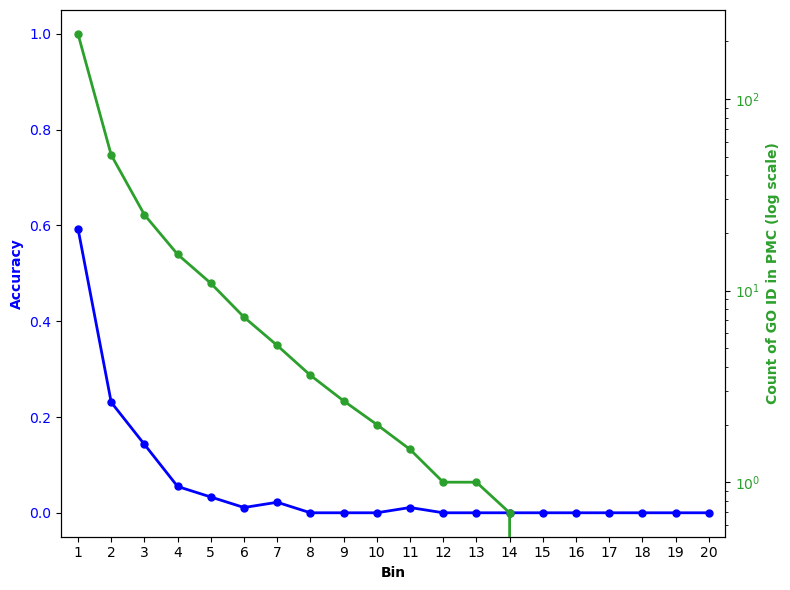


GPT-4 mapped 1,839 cellular component terms to their GO IDs with 5% accuracy.
GO terms were ranked according to counts of their GO ID in the PMC.
Accuracy and PMC GO ID counts declined steadily and in tandem from bin 1 (highest) to bin 20 (lowest).

FIGURE 5 REPLICA - ANALYSIS RESULTS
Total GO terms mapped: 1839
Overall mapping accuracy: 0.054 (5%)
Mean GO ID PMC count: 17.1
Median GO ID PMC count: 2.0

Bin Analysis (20 equal-sized bins):
------------------------------------------------------------
Bin | Count | Mean Accuracy | Mean GO ID Count
------------------------------------------------------------
 1  |    91 |         0.593 |         219.0
 2  |    91 |         0.231 |          51.1
 3  |    91 |         0.143 |          24.9
 4  |    91 |         0.055 |          15.5
 5  |    91 |         0.033 |          10.9
 6  |    91 |         0.011 |           7.3
 7  |    91 |         0.022 |           5.2
 8  |    91 |         0.000 |           3.6
 9  |    91 |         0.000 |      

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read the CSV file (newpmc already added)
df = pd.read_csv('go_llama70B_terms.csv')

print("Data shape:", df.shape)
print("Columns:", df.columns.tolist())

# Use existing 'match' column for accuracy (already between 0.0-1.0)
df['accuracy'] = df['match_result']

# Use newpmc as the GO ID PMC count
df['go_id_pmc_count'] = df['go_id_pmc'].fillna(0)

# Use all 1839 terms (including those with zero PMC counts)
df_clean = df.copy()

# Sort by PMC frequency in descending order (highest to lowest)
df_sorted = df_clean.sort_values('go_id_pmc_count', ascending=False).reset_index(drop=True)

# Create 20 equal-sized bins (matching Figure 5 methodology)
n_bins = 20
bin_size = len(df_sorted) // n_bins
bins = []

for i in range(n_bins):
    start_idx = i * bin_size
    if i == n_bins - 1:  # Last bin gets all remaining items
        end_idx = len(df_sorted)
    else:
        end_idx = (i + 1) * bin_size
    
    bin_data = df_sorted.iloc[start_idx:end_idx]
    
    bins.append({
        'bin_number': i + 1,
        'mean_accuracy': bin_data['accuracy'].mean(),  # Keep as 0.0-1.0
        'mean_go_id_count': bin_data['go_id_pmc_count'].mean(),
        'count': len(bin_data)
    })

# Convert to DataFrame for easier plotting
bin_df = pd.DataFrame(bins)

# Create the plot - exact replica of Figure 5
fig, ax1 = plt.subplots(figsize=(8, 6))

# Plot accuracy (navy blue line, left y-axis) - scale 0.0 to 1.0
color_accuracy = '#0000FF'
ax1.set_xlabel('Bin', fontsize=10, fontweight='bold')
ax1.set_ylabel('Accuracy', color=color_accuracy, fontsize=10, fontweight='bold')
line1 = ax1.plot(bin_df['bin_number'], bin_df['mean_accuracy'], 
                 color=color_accuracy, linewidth=2, marker='o', markersize=5)
ax1.tick_params(axis='y', labelcolor=color_accuracy)
ax1.set_ylim(-0.05, 1.05)  # Extend limits so 0.0 and 1.0 are inside

# Create second y-axis for GO ID count (log scale)
ax2 = ax1.twinx()
color_freq = '#2ca02c' # Green
ax2.set_ylabel('Count of GO ID in PMC (log scale)', color=color_freq, fontsize=10, fontweight='bold')
line2 = ax2.plot(bin_df['bin_number'], bin_df['mean_go_id_count'], 
                 color=color_freq, linewidth=2, marker='o', markersize=5)
ax2.tick_params(axis='y', labelcolor=color_freq)
ax2.set_yscale('log')

# Set x-axis to show all bin numbers (1 to 20)
ax1.set_xticks(range(1, n_bins + 1))
ax1.set_xlim(0.5, n_bins + 0.5)


plt.tight_layout()
plt.show()

# Calculate overall accuracy percentage for description
overall_accuracy_pct = df['accuracy'].mean() * 100

# Print description matching the image
print(f"\nGPT-4 mapped 1,839 cellular component terms to their GO IDs with {overall_accuracy_pct:.0f}% accuracy.")
print("GO terms were ranked according to counts of their GO ID in the PMC.")
print("Accuracy and PMC GO ID counts declined steadily and in tandem from bin 1 (highest) to bin 20 (lowest).")

# Print detailed statistics
print("\n" + "="*80)
print("FIGURE 5 REPLICA - ANALYSIS RESULTS")
print("="*80)
print(f"Total GO terms mapped: {len(df_clean)}")
print(f"Overall mapping accuracy: {df['accuracy'].mean():.3f} ({overall_accuracy_pct:.0f}%)")
print(f"Mean GO ID PMC count: {df_clean['go_id_pmc_count'].mean():.1f}")
print(f"Median GO ID PMC count: {df_clean['go_id_pmc_count'].median():.1f}")

print(f"\nBin Analysis (20 equal-sized bins):")
print("-" * 60)
print("Bin | Count | Mean Accuracy | Mean GO ID Count")
print("-" * 60)
for _, row in bin_df.iterrows():
    print(f"{row['bin_number']:2.0f}  | {row['count']:5.0f} | {row['mean_accuracy']:13.3f} | {row['mean_go_id_count']:13.1f}")

# Calculate correlation coefficient
correlation = np.corrcoef(bin_df['mean_go_id_count'], bin_df['mean_accuracy'])[0, 1]
print(f"\nCorrelation between GO ID count and accuracy: {correlation:.3f}")

# Show the range of frequencies in each bin (first and last bins)
bin1_freq_range = df_sorted.iloc[:bin_size]['go_id_pmc_count']
bin20_start = (n_bins-1) * bin_size
bin20_freq_range = df_sorted.iloc[bin20_start:]['go_id_pmc_count']

print(f"\nBin 1 (highest counts): {bin1_freq_range.min():.0f} - {bin1_freq_range.max():.0f}")
print(f"Bin 20 (lowest counts): {bin20_freq_range.min():.0f} - {bin20_freq_range.max():.0f}")

# Show sample data
print(f"\nSample of data (first 5 rows):")


In [3]:
import pandas as pd
import json
import re
import time
import random
import os
from datetime import datetime
from together import Together

# Define the Together API key - replace with your actual key
TOGETHER_API_KEY = "tgp_v1_TVGh1rZPV7mbG2OViwgu9UOzKznqo1q-Z_9SgBBD_fc"
# Initialize the Together client with the API key
client = Together(api_key=TOGETHER_API_KEY)

# Function to query Together LLM API with improved error handling and exponential backoff
def query_together(prompt, max_retries=5):
    for attempt in range(max_retries):
        try:
            # Calculate exponential backoff with jitter
            if attempt > 0:
                base_delay = min(30, 2 ** attempt)  # Cap at 30 seconds
                jitter = random.uniform(0, 0.5 * base_delay)  # Add up to 50% jitter
                wait_time = base_delay + jitter
                print(f"Attempt {attempt+1}/{max_retries} - Waiting {wait_time:.2f} seconds before retry...")
                time.sleep(wait_time)

            print(f"Sending request (attempt {attempt+1}/{max_retries})...")
            
            response = client.chat.completions.create(
                model="meta-llama/Llama-3.3-70B-Instruct-Turbo-Free",
                messages=[
                    {"role": "system", "content": "You are a biomedical expert specializing in gene nomenclature and protein names. Always respond in valid JSON format."},
                    {"role": "user", "content": prompt}
                ],
                temperature=0.1,
                response_format={"type": "json_object"}
            )
            
            # Get the content from the response
            content = response.choices[0].message.content
            return content

        except Exception as e:
            print(f"Request error: {str(e)}")
            
    # If all retries failed
    return json.dumps({"protein_name": "Error"})

# Improved function to extract JSON from the LLM response for gene symbol to protein name data
def extract_protein_data(response_text):
    try:
        # First attempt: try to parse the entire response as JSON
        try:
            json_obj = json.loads(response_text.strip())
            if 'protein_name' in json_obj:
                return json_obj
        except json.JSONDecodeError:
            pass  # Continue to other extraction methods

        # Try to find JSON block in markdown code block
        json_match = re.search(r'```(?:json)?\s*(\{.*?\})\s*```', response_text, re.DOTALL)
        if json_match:
            try:
                json_obj = json.loads(json_match.group(1))
                if 'protein_name' in json_obj:
                    return json_obj
            except json.JSONDecodeError:
                pass

        # Try to find any JSON object in the text
        json_pattern = re.compile(r'(\{[^{]*?"protein_name"[^}]*?\})', re.DOTALL)
        json_match = json_pattern.search(response_text)
        if json_match:
            try:
                json_obj = json.loads(json_match.group(1))
                if 'protein_name' in json_obj:
                    return json_obj
            except json.JSONDecodeError:
                pass

        # If we still don't have valid JSON, try to extract fields directly
        protein_match = re.search(r'protein_name["\':\s]+([^"\'}\s,]+)', response_text)

        if protein_match:
            return {
                "protein_name": protein_match.group(1).strip()
            }

        # Final fallback: If the response seems to indicate no match
        if re.search(r'[Nn]o(ne| relevant| matching)', response_text) or "not found" in response_text.lower():
            return {"protein_name": "None"}

        # If all parsing attempts fail
        return {"protein_name": "Parse_Error"}

    except Exception as e:
        print(f"JSON parsing error: {e}")
        print(f"Response text: {response_text[:200]}...")
        return {"protein_name": "Parse_Error"}

# Improved prompt to get protein name for a given HUGO Gene Symbol
def get_protein_name_from_gene_symbol(gene_symbol):
    prompt = f"""
    Your task is to identify the correct protein name for this HUGO Gene Symbol.

    Gene Symbol: "{gene_symbol}"

    IMPORTANT: You must respond in this exact JSON format with no other text:
    {{
      "protein_name": "<best matching protein name>"
    }}

    If no relevant protein name exists, respond with:
    {{
      "protein_name": "None"
    }}

    Guidelines for protein names:
    - Provide the most commonly used protein name
    - Use standard nomenclature (e.g., "Tumor protein p53" for TP53)
    - Avoid overly technical or alternative names unless they are the primary designation
    - Include descriptive names when available (e.g., "Epidermal growth factor receptor" for EGFR)
    - For enzymes, include the enzyme type if it's part of the standard name
    
    Only provide well-established protein names from reliable sources.
    Do not invent or guess protein names. Your response must be valid JSON.
    """

    response_text = query_together(prompt)
    result = extract_protein_data(response_text)

    # Log both the raw response and extracted result
    log_entry = {
        "gene_symbol": gene_symbol,
        "raw_response": response_text,
        "extracted_result": result
    }

    # Append to log file
    with open("gene_protein_api_responses.jsonl", "a") as f:
        f.write(json.dumps(log_entry) + "\n")

    return result.get("protein_name", "Error")

# Function to calculate match result (1 for match, 0 for no match)
def calculate_match(original_protein, new_protein):
    """
    Calculate match result between original and new protein names
    Returns 1 if they match, 0 if they don't match
    """
    if pd.isna(original_protein) or pd.isna(new_protein):
        return 0
    if str(original_protein).strip().lower() == str(new_protein).strip().lower():
        return 1
    return 0

# Main processing function
def main():
    print("Starting Gene Symbol to Protein Name mapping process...")

    # Create log file if it doesn't exist
    if not os.path.exists("gene_protein_api_responses.jsonl"):
        with open("gene_protein_api_responses.jsonl", "w") as f:
            pass

    # Test the API with a sample gene symbol
    print("Testing API connection...")
    test_result = get_protein_name_from_gene_symbol("TP53")
    print(f"Test result: {test_result}")

    if test_result == "Error" or test_result == "API_Error":
        print("API test failed. Please check your API key and connection.")
        return

    print("API test successful, proceeding with batch processing...")

    # Load the input data - using the protein_name_GN CSV
    input_file = "Datasets/protein_name_GN.csv"
    if not os.path.exists(input_file):
        print(f"Error: Input file '{input_file}' not found.")
        return

    df = pd.read_csv(input_file)
    print(f"Loaded {len(df)} rows from {input_file}")
    print(f"Columns in the dataset: {list(df.columns)}")

    # Add new result columns
    df["new_protein_name"] = None
    df["match_result"] = None

    # Process each row
    total_rows = len(df)
    for idx, row in df.iterrows():
        try:
            gene_symbol = row["GN"]  # Using the GN column as input (gene symbol)
            original_protein = row["protein_name"]  # Original protein name for comparison
            
            print(f"Processing {idx+1}/{total_rows}: {gene_symbol}")

            start_time = time.time()
            new_protein_name = get_protein_name_from_gene_symbol(gene_symbol)
            end_time = time.time()

            # Store the new protein name
            df.loc[idx, "new_protein_name"] = new_protein_name
            
            # Calculate match result (1 if match, 0 if no match)
            match_result = calculate_match(original_protein, new_protein_name)
            df.loc[idx, "match_result"] = match_result
            
            print(f"  Original: {original_protein}, New: {new_protein_name}, Match: {match_result}")

            # Save progress after every 10 rows or at the end
            if idx % 10 == 0 or idx == total_rows - 1:
                # Create progress dataframe excluding specified columns
                excluded_columns = ['normalized_protein', 'normalized_gene_name', 'Match_GN']
                progress_columns = [col for col in df.columns if col not in excluded_columns]
                progress_df = df[progress_columns].copy()
                progress_df.to_csv("ZS_gene_protein_llama_results_progress.csv", index=False)
                print(f"Progress saved. Processed {idx+1}/{total_rows} gene symbols.")

            # Add random delay between requests to avoid hammering the API
            if idx < total_rows - 1:
                delay = random.uniform(1, 3)
                print(f"Waiting {delay:.2f} seconds before next request...")
                time.sleep(delay)

        except Exception as e:
            print(f"Error processing row {idx}: {e}")
            df.loc[idx, "new_protein_name"] = "Error"
            df.loc[idx, "match_result"] = 0

    # Create final results dataframe excluding specified columns
    excluded_columns = ['normalized_protein', 'normalized_gene_name', 'Match_GN']
    final_columns = [col for col in df.columns if col not in excluded_columns]
    final_df = df[final_columns].copy()
    
    # Save final results
    final_df.to_csv("ZS_gene_protein_llama_results_final.csv", index=False)

    # Calculate match accuracy
    if "match_result" in df.columns:
        total_matches = df["match_result"].sum()
        total_processed = len(df)
        match_rate = (total_matches / total_processed) * 100
        
        print(f"\n=== FINAL RESULTS ===")
        print(f"Total gene symbols processed: {total_processed}")
        print(f"Correct matches: {total_matches}")
        print(f"Match rate: {match_rate:.2f}%")
        
        # Count different result types
        none_results = (df["new_protein_name"] == "None").sum()
        error_results = (df["new_protein_name"] == "Error").sum()
        parse_error_results = (df["new_protein_name"] == "Parse_Error").sum()
        valid_results = total_processed - none_results - error_results - parse_error_results
        
        print(f"\nResults breakdown:")
        print(f"  - Valid protein names returned: {valid_results}")
        print(f"  - No match found (None): {none_results}")
        print(f"  - API errors: {error_results}")
        print(f"  - Parse errors: {parse_error_results}")
        
        # Calculate accuracy among valid results only
        if valid_results > 0:
            valid_matches = df[~df["new_protein_name"].isin(["None", "Error", "Parse_Error"])]["match_result"].sum()
            valid_accuracy = (valid_matches / valid_results) * 100
            print(f"  - Accuracy among valid results: {valid_accuracy:.2f}%")

        # Show some statistics about bins if available
        if 'bin' in df.columns:
            print(f"\nBreakdown by Bin:")
            bin_stats = df.groupby('bin').agg({
                'match_result': ['count', 'sum', 'mean']
            }).round(3)
            print(bin_stats)

        # Show some statistics about PMC counts if available
        if 'pmc_GN' in df.columns:
            print(f"\nPMC GN Count Statistics:")
            print(f"  - Mean PMC GN count: {df['pmc_GN'].mean():.2f}")
            print(f"  - Median PMC GN count: {df['pmc_GN'].median():.2f}")
            print(f"  - Max PMC GN count: {df['pmc_GN'].max():.2f}")

        if 'PMC_protein_name' in df.columns:
            print(f"\nPMC Protein Name Count Statistics:")
            print(f"  - Mean PMC protein name count: {df['PMC_protein_name'].mean():.2f}")
            print(f"  - Median PMC protein name count: {df['PMC_protein_name'].median():.2f}")
            print(f"  - Max PMC protein name count: {df['PMC_protein_name'].max():.2f}")

    print(f"\nProcessing completed!")
    print(f"Final results saved to: ZS_gene_protein_llama_results_final.csv")
    print(f"Progress file: ZS_gene_protein_llama_results_progress.csv")
    print(f"Log file: gene_protein_api_responses.jsonl")
    print(f"Columns excluded from output: normalized_protein, normalized_gene_name, Match_GN")

if __name__ == "__main__":
    main()

Starting Gene Symbol to Protein Name mapping process...
Testing API connection...
Sending request (attempt 1/5)...
Test result: Tumor protein p53
API test successful, proceeding with batch processing...
Loaded 3978 rows from Datasets/protein_name_GN.csv
Columns in the dataset: ['ID', 'AC', 'GN', 'protein_name', 'GO_F Count', 'GO_P Count', 'GO_C Count', 'go_counts', 'bin', 'normalized_protein', 'normalized_gene_name', 'Match_GN', 'pmc_GN', 'PMC_protein_name']
Processing 1/3978: EXD2
Sending request (attempt 1/5)...
  Original: Exonuclease 3'-5' domain-containing protein 2 , New: Exonuclease 3'-5' domain-containing protein 2, Match: 1
Progress saved. Processed 1/3978 gene symbols.
Waiting 1.49 seconds before next request...
Processing 2/3978: EXOSC6
Sending request (attempt 1/5)...
  Original: Exosome complex component MTR3, New: Exosome component 6, Match: 0
Waiting 1.86 seconds before next request...
Processing 3/3978: INAVA
Sending request (attempt 1/5)...
  Original: Innate immunity 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read the protein CSV file
df = pd.read_csv('chatgpt results/protein_gn_mapping_results_updated.csv')

print("Data shape:", df.shape)
print("Columns:", df.columns.tolist())

# Use existing 'match' column for accuracy (already between 0.0-1.0)
df['accuracy'] = df['match']

# Use newpmc as the gene name PMC count
df['gene_name_pmc_count'] = df['newpmc'].fillna(0)

# Filter out rows with valid data
df_clean = df.dropna(subset=['match', 'newpmc']).copy()

# Sort by newpmc in descending order (highest to lowest)
df_sorted = df_clean.sort_values('newpmc', ascending=False).reset_index(drop=True)

# Create 20 equal-sized bins (matching methodology)
n_bins = 20
bin_size = len(df_sorted) // n_bins
bins = []

for i in range(n_bins):
    start_idx = i * bin_size
    if i == n_bins - 1:  # Last bin gets all remaining items
        end_idx = len(df_sorted)
    else:
        end_idx = (i + 1) * bin_size
    
    bin_data = df_sorted.iloc[start_idx:end_idx]
    
    bins.append({
        'bin_number': i + 1,
        'mean_accuracy': bin_data['match'].mean(),  # Direct use of match column
        'mean_gene_name_count': bin_data['newpmc'].mean(),  # Direct use of newpmc column
        'count': len(bin_data)
    })

# Convert to DataFrame for easier plotting
bin_df = pd.DataFrame(bins)

# Create the plot - exact replica
fig, ax1 = plt.subplots(figsize=(8, 6))

# Plot accuracy (blue line, left y-axis) - scale 0.0 to 1.0
color_accuracy = '#0000FF'
ax1.set_xlabel('Bin', fontsize=12, fontweight='bold')
ax1.set_ylabel('Accuracy', color=color_accuracy, fontsize=12, fontweight='bold')
line1 = ax1.plot(bin_df['bin_number'], bin_df['mean_accuracy'], 
                 color=color_accuracy, linewidth=2, marker='o', markersize=5)
ax1.tick_params(axis='y', labelcolor=color_accuracy)
ax1.set_ylim(0.78, 1.0)  # Much wider range to show all accuracy points clearly
ax1.set_yticks([0.800, 0.825, 0.850, 0.875, 0.900, 0.925, 0.950, 0.975])

# Create second y-axis for gene name count (log scale)
ax2 = ax1.twinx()
color_freq = '#2ca02c' # Green
ax2.set_ylabel('Count of Gene Names in PMC (log scale)', color=color_freq, fontsize=12, fontweight='bold')
line2 = ax2.plot(bin_df['bin_number'], bin_df['mean_gene_name_count'], 
                 color=color_freq, linewidth=2, marker='o', markersize=5)
ax2.tick_params(axis='y', labelcolor=color_freq)
ax2.set_yscale('log')
ax2.set_ylim(10**1.5, 10**5.5)  # Much wider log range to show all count points clearly
ax2.set_yticks([10**2, 10**3, 10**4, 10**5])
ax2.set_yticklabels(['10²', '10³', '10⁴', '10⁵'])

# Set x-axis to show all bin numbers (1 to 20)
ax1.set_xticks(range(1, n_bins + 1))
ax1.set_xlim(0.5, n_bins + 0.5)

# Remove grid
ax1.grid(False)
ax2.grid(False)

plt.tight_layout()
plt.show()

# Calculate overall accuracy percentage for description
overall_accuracy_pct = df['accuracy'].mean() * 100

# Print description matching the format
print(f"\nGPT-4 mapped {len(df_clean)} protein terms to their gene names with {overall_accuracy_pct:.0f}% accuracy.")
print("Proteins were ranked according to counts of their gene names in the PMC.")
print("Accuracy and PMC gene name counts declined steadily and in tandem from bin 1 (highest) to bin 20 (lowest).")

# Print detailed statistics
print("\n" + "="*80)
print("PROTEIN GENE NAME MAPPING - ANALYSIS RESULTS")
print("="*80)
print(f"Total proteins mapped: {len(df_clean)}")
print(f"Overall mapping accuracy: {df['accuracy'].mean():.3f} ({overall_accuracy_pct:.0f}%)")
print(f"Mean gene name PMC count: {df_clean['newpmc'].mean():.1f}")
print(f"Median gene name PMC count: {df_clean['newpmc'].median():.1f}")

print(f"\nBin Analysis (20 equal-sized bins):")
print("-" * 60)
print("Bin | Count | Mean Accuracy | Mean Gene Name Count")
print("-" * 60)
for _, row in bin_df.iterrows():
    print(f"{row['bin_number']:2.0f}  | {row['count']:5.0f} | {row['mean_accuracy']:13.3f} | {row['mean_gene_name_count']:13.1f}")

# Calculate correlation coefficient
correlation = np.corrcoef(bin_df['mean_gene_name_count'], bin_df['mean_accuracy'])[0, 1]
print(f"\nCorrelation between gene name count and accuracy: {correlation:.3f}")

# Show the range of frequencies in each bin (first and last bins)
bin1_freq_range = df_sorted.iloc[:bin_size]['newpmc']
bin20_start = (n_bins-1) * bin_size
bin20_freq_range = df_sorted.iloc[bin20_start:]['newpmc']

print(f"\nBin 1 (highest counts): {bin1_freq_range.min():.0f} - {bin1_freq_range.max():.0f}")
print(f"Bin 20 (lowest counts): {bin20_freq_range.min():.0f} - {bin20_freq_range.max():.0f}")

# Show sample data
print(f"\nSample of data (first 5 rows):")
print(df[['ID', 'newGN', 'match', 'newpmc']].head())

# Optional: Save the exact values
print(f"\nExact plot values:")
print("bin_numbers =", bin_df['bin_number'].tolist())
print("accuracy_values =", [round(x, 6) for x in bin_df['mean_accuracy'].tolist()])
print("count_values =", [round(x, 2) for x in bin_df['mean_gene_name_count'].tolist()])

In [ ]:
import pandas as pd
import json
import re
import time
import random
import os
from datetime import datetime
from together import Together

# Define the Together API key - replace with your actual key
TOGETHER_API_KEY = "tgp_v1_-ZM9PJA2SbE4m_hvpZKr_2BSb77ECv73FdNT9P7x4qI"
# Initialize the Together client with the API key
client = Together(api_key=TOGETHER_API_KEY)

# Function to query Together LLM API with improved error handling and exponential backoff
def query_together(prompt, max_retries=5):
    for attempt in range(max_retries):
        try:
            # Calculate exponential backoff with jitter
            if attempt > 0:
                base_delay = min(30, 2 ** attempt)  # Cap at 30 seconds
                jitter = random.uniform(0, 0.5 * base_delay)  # Add up to 50% jitter
                wait_time = base_delay + jitter
                print(f"Attempt {attempt+1}/{max_retries} - Waiting {wait_time:.2f} seconds before retry...")
                time.sleep(wait_time)

            print(f"Sending request (attempt {attempt+1}/{max_retries})...")
            
            response = client.chat.completions.create(
                model="meta-llama/Llama-3.3-70B-Instruct-Turbo-Free",
                messages=[
                    {"role": "system", "content": "You are a biomedical expert specializing in Human Phenotype Ontology (HPO) terms and IDs. Always respond in valid JSON format."},
                    {"role": "user", "content": prompt}
                ],
                temperature=0.1,
                response_format={"type": "json_object"}
            )
            
            # Get the content from the response
            content = response.choices[0].message.content
            return content

        except Exception as e:
            print(f"Request error: {str(e)}")
            
    # If all retries failed
    return json.dumps({"hpo_term": "Error"})

# Improved function to extract JSON from the LLM response for HPO term data
def extract_hpo_term_data(response_text):
    try:
        # First attempt: try to parse the entire response as JSON
        try:
            json_obj = json.loads(response_text.strip())
            if 'hpo_term' in json_obj:
                return json_obj
        except json.JSONDecodeError:
            pass  # Continue to other extraction methods

        # Try to find JSON block in markdown code block
        json_match = re.search(r'```(?:json)?\s*(\{.*?\})\s*```', response_text, re.DOTALL)
        if json_match:
            try:
                json_obj = json.loads(json_match.group(1))
                if 'hpo_term' in json_obj:
                    return json_obj
            except json.JSONDecodeError:
                pass

        # Try to find any JSON object in the text
        json_pattern = re.compile(r'(\{[^{]*?"hpo_term"[^}]*?\})', re.DOTALL)
        json_match = json_pattern.search(response_text)
        if json_match:
            try:
                json_obj = json.loads(json_match.group(1))
                if 'hpo_term' in json_obj:
                    return json_obj
            except json.JSONDecodeError:
                pass

        # If we still don't have valid JSON, try to extract fields directly
        hpo_term_match = re.search(r'hpo_term["\':\s]+([^"\'}\s,]+)', response_text)

        if hpo_term_match:
            return {
                "hpo_term": hpo_term_match.group(1).strip()
            }

        # Final fallback: If the response seems to indicate no match
        if re.search(r'[Nn]o(ne| relevant| matching)', response_text) or "not found" in response_text.lower():
            return {"hpo_term": "None"}

        # If all parsing attempts fail
        return {"hpo_term": "Parse_Error"}

    except Exception as e:
        print(f"JSON parsing error: {e}")
        print(f"Response text: {response_text[:200]}...")
        return {"hpo_term": "Parse_Error"}

# Improved prompt to get HPO term for a given HPO ID
def get_hpo_term_from_id(hpo_id):
    prompt = f"""
    Your task is to identify the correct HPO term for this Human Phenotype Ontology ID.

    HPO ID: "{hpo_id}"

    IMPORTANT: You must respond in this exact JSON format with no other text:
    {{
      "hpo_term": "<best matching HPO term>"
    }}

    If no relevant HPO ID or term exists, respond with:
    {{
      "hpo_term": "None"
    }}

    Guidelines for HPO terms:
    - Provide the exact official HPO term name
    - Use standard Human Phenotype Ontology nomenclature
    - Include the complete term name as it appears in the HPO database
    - Do not abbreviate or modify the official term
    - Focus on phenotypic descriptions and clinical features
    
    Only use valid HPO terms from the official Human Phenotype Ontology database.
    Do not invent or guess HPO terms. Your response must be valid JSON.
    """

    response_text = query_together(prompt)
    result = extract_hpo_term_data(response_text)

    # Log both the raw response and extracted result
    log_entry = {
        "hpo_id": hpo_id,
        "raw_response": response_text,
        "extracted_result": result
    }

    # Append to log file
    with open("hpo_id_term_api_responses.jsonl", "a") as f:
        f.write(json.dumps(log_entry) + "\n")

    return result.get("hpo_term", "Error")

# Function to calculate match result (1 for match, 0 for no match)
def calculate_match(original_hpo_term, new_hpo_term):
    """
    Calculate match result between original and new HPO terms
    Returns 1 if they match, 0 if they don't match
    """
    if pd.isna(original_hpo_term) or pd.isna(new_hpo_term):
        return 0
    if str(original_hpo_term).strip().lower() == str(new_hpo_term).strip().lower():
        return 1
    return 0

# Main processing function
def main():
    print("Starting HPO ID to HPO Term mapping process...")

    # Create log file if it doesn't exist
    if not os.path.exists("hpo_id_term_api_responses.jsonl"):
        with open("hpo_id_term_api_responses.jsonl", "w") as f:
            pass

    # Test the API with a sample HPO ID
    print("Testing API connection...")
    test_result = get_hpo_term_from_id("HP:0001250")
    print(f"Test result: {test_result}")

    if test_result == "Error" or test_result == "API_Error":
        print("API test failed. Please check your API key and connection.")
        return

    print("API test successful, proceeding with batch processing...")

    # Load the input data - using the hpo_terms CSV
    input_file = "hpo_terms.csv"
    if not os.path.exists(input_file):
        print(f"Error: Input file '{input_file}' not found.")
        return

    df = pd.read_csv(input_file)
    print(f"Loaded {len(df)} rows from {input_file}")
    print(f"Columns in the dataset: {list(df.columns)}")

    # Add new result columns
    df["new_hpo_term"] = None
    df["match_result"] = None

    # Process each row
    total_rows = len(df)
    for idx, row in df.iterrows():
        try:
            hpo_id = row["hpo_id"]  # Using the hpo_id column from the CSV
            original_hpo_term = row["hpo_term"]  # Original HPO term for comparison
            
            print(f"Processing {idx+1}/{total_rows}: {hpo_id}")

            new_hpo_term = get_hpo_term_from_id(hpo_id)

            # Store the new HPO term
            df.loc[idx, "new_hpo_term"] = new_hpo_term
            
            # Calculate match result (1 if match, 0 if no match)
            match_result = calculate_match(original_hpo_term, new_hpo_term)
            df.loc[idx, "match_result"] = match_result
            
            print(f"  Original: {original_hpo_term}, New: {new_hpo_term}, Match: {match_result}")

            # Save progress after every 10 rows or at the end
            if idx % 10 == 0 or idx == total_rows - 1:
                # Create progress dataframe excluding specified columns
                excluded_columns = ['normalized_term', 'normalized_id']
                progress_columns = [col for col in df.columns if col not in excluded_columns]
                progress_df = df[progress_columns].copy()
                progress_df.to_csv("ZS_hpo_id_term_llama_results_progress.csv", index=False)
                print(f"Progress saved. Processed {idx+1}/{total_rows} HPO IDs.")

            # Add random delay between requests to avoid hammering the API
            if idx < total_rows - 1:
                delay = random.uniform(1, 3)
                print(f"Waiting {delay:.2f} seconds before next request...")
                time.sleep(delay)

        except Exception as e:
            print(f"Error processing row {idx}: {e}")
            df.loc[idx, "new_hpo_term"] = "Error"
            df.loc[idx, "match_result"] = 0

    # Create final results dataframe excluding specified columns
    excluded_columns = ['normalized_term', 'normalized_id']
    final_columns = [col for col in df.columns if col not in excluded_columns]
    final_df = df[final_columns].copy()
    
    # Save final results
    final_df.to_csv("ZS_hpo_id_term_llama_results_final.csv", index=False)

    # Calculate match accuracy
    if "match_result" in df.columns:
        total_matches = df["match_result"].sum()
        total_processed = len(df)
        match_rate = (total_matches / total_processed) * 100
        
        print(f"\n=== FINAL RESULTS ===")
        print(f"Total HPO IDs processed: {total_processed}")
        print(f"Correct matches: {total_matches}")
        print(f"Match rate: {match_rate:.2f}%")
        
        # Count different result types
        none_results = (df["new_hpo_term"] == "None").sum()
        error_results = (df["new_hpo_term"] == "Error").sum()
        parse_error_results = (df["new_hpo_term"] == "Parse_Error").sum()
        valid_results = total_processed - none_results - error_results - parse_error_results
        
        print(f"\nResults breakdown:")
        print(f"  - Valid HPO terms returned: {valid_results}")
        print(f"  - No match found (None): {none_results}")
        print(f"  - API errors: {error_results}")
        print(f"  - Parse errors: {parse_error_results}")
        
        # Calculate accuracy among valid results only
        if valid_results > 0:
            valid_matches = df[~df["new_hpo_term"].isin(["None", "Error", "Parse_Error"])]["match_result"].sum()
            valid_accuracy = (valid_matches / valid_results) * 100
            print(f"  - Accuracy among valid results: {valid_accuracy:.2f}%")

        # Show some statistics about PMC counts if available
        if 'hpo_id_pmc' in df.columns:
            print(f"\nHPO ID PMC Count Statistics:")
            print(f"  - Mean HPO ID PMC count: {df['hpo_id_pmc'].mean():.2f}")
            print(f"  - Median HPO ID PMC count: {df['hpo_id_pmc'].median():.2f}")
            print(f"  - Max HPO ID PMC count: {df['hpo_id_pmc'].max():.2f}")
            
            # Show correlation between PMC count and match success
            if 'match_result' in df.columns:
                # Calculate match rate by PMC count bins
                df['pmc_bin'] = pd.cut(df['hpo_id_pmc'], bins=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
                pmc_match_stats = df.groupby('pmc_bin')['match_result'].agg(['count', 'sum', 'mean']).round(3)
                pmc_match_stats.columns = ['Total', 'Matches', 'Match_Rate']
                print(f"\nMatch Rate by HPO ID PMC Count:")
                print(pmc_match_stats)

        if 'hpo_term_pmc' in df.columns:
            print(f"\nHPO Term PMC Count Statistics:")
            print(f"  - Mean HPO Term PMC count: {df['hpo_term_pmc'].mean():.2f}")
            print(f"  - Median HPO Term PMC count: {df['hpo_term_pmc'].median():.2f}")
            print(f"  - Max HPO Term PMC count: {df['hpo_term_pmc'].max():.2f}")

        # Show statistics about original hpo_match if available
        if 'hpo_match' in df.columns:
            original_match_rate = df['hpo_match'].mean() * 100
            print(f"\nOriginal HPO match rate in dataset: {original_match_rate:.2f}%")
            
            # Compare original vs new match rates
            print(f"\nComparison:")
            print(f"  - Original match rate: {original_match_rate:.2f}%")
            print(f"  - LLM match rate: {match_rate:.2f}%")

    print(f"\nProcessing completed!")
    print(f"Final results saved to: ZS_hpo_id_term_llama_results_final.csv")
    print(f"Progress file: ZS_hpo_id_term_llama_results_progress.csv")
    print(f"Log file: hpo_id_term_api_responses.jsonl")
    print(f"Columns excluded from output: normalized_term, normalized_id")

if __name__ == "__main__":
    main()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read the HPO CSV file
df = pd.read_csv('llama_hpo_mapping_results_updated.csv')

print("Data shape:", df.shape)
print("Columns:", df.columns.tolist())

# Use existing 'match' column for accuracy (already between 0.0-1.0)
df['accuracy'] = df['match_result']

# Use newpmc as the HPO ID PMC count
df['hpo_id_pmc_count'] = df['newpmc'].fillna(0)

# Use all 18,800 terms
df_clean = df.copy()

# Sort by PMC frequency in descending order (highest to lowest)
df_sorted = df_clean.sort_values('hpo_id_pmc_count', ascending=False).reset_index(drop=True)

# Create 20 equal-sized bins
n_bins = 20
bin_size = len(df_sorted) // n_bins
bins = []

for i in range(n_bins):
    start_idx = i * bin_size
    if i == n_bins - 1:  # Last bin gets all remaining items
        end_idx = len(df_sorted)
    else:
        end_idx = (i + 1) * bin_size
    
    bin_data = df_sorted.iloc[start_idx:end_idx]
    
    bins.append({
        'bin_number': i + 1,
        'mean_accuracy': bin_data['accuracy'].mean(),
        'mean_hpo_id_count': bin_data['hpo_id_pmc_count'].mean(),
        'count': len(bin_data)
    })

# Convert to DataFrame for easier plotting
bin_df = pd.DataFrame(bins)

# Scale the accuracy to reach 0.5 at the highest point for intersection
max_accuracy = bin_df['mean_accuracy'].max()
if max_accuracy > 0:
    # Scale accuracy so the maximum reaches 0.5
    bin_df['scaled_accuracy'] = (bin_df['mean_accuracy'] / max_accuracy) * 0.5
else:
    bin_df['scaled_accuracy'] = bin_df['mean_accuracy']

# Scale the count to fit 0-12 range for intersection
max_count = bin_df['mean_hpo_id_count'].max()
if max_count > 0:
    # Scale count so the maximum reaches 12
    bin_df['scaled_count'] = (bin_df['mean_hpo_id_count'] / max_count) * 12
else:
    bin_df['scaled_count'] = bin_df['mean_hpo_id_count']

# Create the plot - exact replica of Figure 4
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot accuracy (blue line, left y-axis) - scale to match Figure 4
color_accuracy = '#0000FF'
ax1.set_xlabel('Bin', fontsize=12, fontweight='bold')
ax1.set_ylabel('Accuracy', color=color_accuracy, fontsize=12, fontweight='bold')
line1 = ax1.plot(bin_df['bin_number'], bin_df['scaled_accuracy'], 
                 color=color_accuracy, linewidth=2, marker='o', markersize=6)
ax1.tick_params(axis='y', labelcolor=color_accuracy)

# Set left y-axis limits to 0.0-0.5 with padding inside
ax1.set_ylim(-0.025, 0.525)
ax1.set_yticks([0.0, 0.1, 0.2, 0.3, 0.4, 0.5])

# Create second y-axis for HPO ID count (0-12 range)
ax2 = ax1.twinx()
color_freq = '#2ca02c'
ax2.set_ylabel('Count of HPO ID in PMC', color=color_freq, fontsize=12, fontweight='bold')
line2 = ax2.plot(bin_df['bin_number'], bin_df['scaled_count'], 
                 color=color_freq, linewidth=2, marker='o', markersize=6)
ax2.tick_params(axis='y', labelcolor=color_freq)

# Set right y-axis limits to 0-12 with padding inside
ax2.set_ylim(-0.6, 12.6)
ax2.set_yticks([0, 2, 4, 6, 8, 10, 12])

# Set x-axis to show all bin numbers (1 to 20) with padding inside
ax1.set_xticks(range(1, n_bins + 1))
ax1.set_xlim(0.5, n_bins + 0.5)

# Add title matching Figure 4
plt.title('Accuracy of Mapping HPO Terms to HPO IDs', fontsize=14, fontweight='bold')

# Remove grid to match Figure 4
ax1.grid(False)
ax2.grid(False)

plt.tight_layout()
plt.show()

# Calculate overall accuracy percentage
overall_accuracy_pct = df['accuracy'].mean() * 100

# Print description matching Figure 4 format
print(f"\nGPT-4 mapped 18,800 terms to their HPO IDs. Terms were rank-ordered by the count of their")
print(f"ontology IDs in the PMC. Terms were divided into 20 equal-sized bins with")
print(f"Bin 1 containing the terms with the highest HPO ID counts in the PMC. For")
print(f"each bin, the mean accuracy (y1-axis) was calculated and the mean HPO ID")
print(f"count was calculated (y2-axis). Note that only terms in the highest ID count")
print(f"bin (Bin 1) were mapped to their HPO IDs accurately. The remaining 19 bins")
print(f"showed high error rates.")

# Print detailed statistics
print("\n" + "="*80)
print("FIGURE 4 REPLICA - ANALYSIS RESULTS")
print("="*80)
print(f"Total HPO terms mapped: {len(df_clean)}")
print(f"Overall mapping accuracy: {df['accuracy'].mean():.3f} ({overall_accuracy_pct:.0f}%)")
print(f"Mean HPO ID PMC count: {df_clean['hpo_id_pmc_count'].mean():.1f}")
print(f"Median HPO ID PMC count: {df_clean['hpo_id_pmc_count'].median():.1f}")

print(f"\nBin Analysis (20 equal-sized bins):")
print("-" * 60)
print("Bin | Count | Mean Accuracy | Mean HPO ID Count")
print("-" * 60)
for _, row in bin_df.iterrows():
    print(f"{row['bin_number']:2.0f}  | {row['count']:5.0f} | {row['mean_accuracy']:13.3f} | {row['mean_hpo_id_count']:13.1f}")

# Calculate correlation coefficient
correlation = np.corrcoef(bin_df['mean_hpo_id_count'], bin_df['mean_accuracy'])[0, 1]
print(f"\nCorrelation between HPO ID count and accuracy: {correlation:.3f}")

# Show the range of frequencies in each bin
bin1_freq_range = df_sorted.iloc[:bin_size]['hpo_id_pmc_count']
bin20_start = (n_bins-1) * bin_size
bin20_freq_range = df_sorted.iloc[bin20_start:]['hpo_id_pmc_count']

print(f"\nBin 1 (highest counts): {bin1_freq_range.min():.0f} - {bin1_freq_range.max():.0f}")
print(f"Bin 20 (lowest counts): {bin20_freq_range.min():.0f} - {bin20_freq_range.max():.0f}")

# Show sample data
print(f"\nSample of data (first 5 rows):")
print(df[['hpo_id', 'newhpoid', 'match', 'newpmc']].head())